# K-Means Cluster Analysis on the Diana Dataset
## Identifying Distinct Diabetes Phenotypes

**Methodology:** Following the 2025 systematic review *"Cluster Analysis in Diabetes Research"*

---

### Objective
Perform unsupervised K-means cluster analysis on the Diana dataset to identify distinct diabetes phenotypes, using 11 clinical and metabolic variables.

### Clustering Variables
| Variable | Description |
|----------|-------------|
| `age` | Age in years |
| `hba1c` | Glycated hemoglobin (%) |
| `fbs` | Fasting blood sugar (mg/dL) |
| `bmi` | Body mass index (kg/m²) |
| `total_cholesterol` | Total cholesterol (mg/dL) |
| `ldl` | Low-density lipoprotein (mg/dL) |
| `hdl` | High-density lipoprotein (mg/dL) |
| `triglycerides` | Triglycerides (mg/dL) |
| `systolic` | Systolic blood pressure (mmHg) |
| `diastolic` | Diastolic blood pressure (mmHg) |
| `waist_circumference` | Waist circumference (cm) |

### Pipeline
1. Data loading & preprocessing (missing value handling)
2. MinMaxScaler normalization to [0, 1]
3. Optimal *k* determination (Elbow + Silhouette)
4. K-Means clustering (k=5)
5. Cluster profiling (Median + IQR)
6. Phenotype interpretation & comparison to reference study
7. Visualizations (Radar, Box plots, Silhouette, Heatmap)

---
## 1. Setup & Imports

In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy import stats
from IPython.display import display, Markdown
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

OUTPUT_DIR = os.path.join(os.getcwd(), "clustering_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLUSTERING_VARS = [
    "age", "hba1c", "fbs", "bmi", "total_cholesterol",
    "ldl", "hdl", "triglycerides", "systolic", "diastolic",
    "waist_circumference"
]

VAR_LABELS = {
    "age": "Age (years)",
    "hba1c": "HbA1c (%)",
    "fbs": "FBS (mg/dL)",
    "bmi": "BMI (kg/m\u00b2)",
    "total_cholesterol": "Total Chol. (mg/dL)",
    "ldl": "LDL (mg/dL)",
    "hdl": "HDL (mg/dL)",
    "triglycerides": "Triglycerides (mg/dL)",
    "systolic": "Systolic BP (mmHg)",
    "diastolic": "Diastolic BP (mmHg)",
    "waist_circumference": "Waist Circ. (cm)"
}

CLUSTER_COLORS = ["#2563eb", "#dc2626", "#059669", "#d97706", "#7c3aed"]
K_RANGE = range(2, 11)

print("Setup complete.")

Setup complete.


---
## 2. Data Loading & Exploration

In [19]:
df = pd.read_csv("diana_dataset_binary.csv")

print(f"Dataset shape: {df.shape[0]} patients x {df.shape[1]} features")
print(f"\nDiabetes status distribution:")
display(df['diabetes_status'].value_counts().to_frame('Count'))

print(f"\nFirst 5 rows of clustering variables:")
display(df[CLUSTERING_VARS].head())

Dataset shape: 1376 patients x 22 features

Diabetes status distribution:


,Count
diabetes_status,
Normal,642
Pre-diabetic,457
Diabetic,277



First 5 rows of clustering variables:


,age,hba1c,fbs,bmi,total_cholesterol,ldl,hdl,triglycerides,systolic,diastolic,waist_circumference
0,56.0,5.0,104.0,27.3,214.0,124.0,68.0,108.5,122.0,79.0,97.9
1,59.0,5.3,91.0,32.9,189.0,126.0,47.0,90.8,135.0,85.0,88.3
2,54.0,6.1,99.0,50.2,184.0,125.0,41.0,172.2,99.0,78.0,133.0
3,52.0,5.5,94.0,30.9,191.0,119.0,53.0,73.9,128.0,84.0,98.8
4,51.0,5.9,115.0,39.2,207.0,102.0,49.0,200.5,123.0,93.0,126.2


---
## 3. Data Preprocessing

### 3a. Missing Value Assessment
Missing values are handled via **median imputation** (if any exist).

In [20]:
X_raw = df[CLUSTERING_VARS].copy()

missing = X_raw.isnull().sum()
missing_any = missing[missing > 0]

if missing_any.empty:
    print("No missing values detected in any clustering variable.")
else:
    print("Missing values found:")
    display(missing_any.to_frame('Missing Count'))
    for col in missing_any.index:
        median_val = X_raw[col].median()
        X_raw[col].fillna(median_val, inplace=True)
        print(f"  -> {col}: imputed {missing_any[col]} values with median = {median_val:.2f}")

No missing values detected in any clustering variable.


### 3b. Descriptive Statistics (Raw Values)

In [21]:
raw_desc = X_raw.describe().round(2)
raw_desc.columns = [VAR_LABELS.get(c, c) for c in raw_desc.columns]
display(raw_desc)

,Age (years),HbA1c (%),FBS (mg/dL),BMI (kg/m²),Total Chol. (mg/dL),LDL (mg/dL),HDL (mg/dL),Triglycerides (mg/dL),Systolic BP (mmHg),Diastolic BP (mmHg),Waist Circ. (cm)
count,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00,1376.00
mean,54.59,5.97,112.01,31.09,209.34,125.67,58.89,124.63,124.11,73.48,101.59
std,4.11,1.13,37.64,7.97,42.15,37.55,16.59,75.55,18.06,11.22,16.70
min,45.00,4.10,47.00,13.60,86.00,24.00,23.00,24.00,82.00,30.00,66.30
25%,52.00,5.40,95.00,25.49,181.00,101.00,47.00,77.00,112.00,66.00,89.68
50%,55.00,5.70,102.00,29.70,207.00,123.00,56.00,106.70,122.00,73.00,100.10
75%,58.00,6.00,112.00,35.70,234.00,148.00,67.25,149.00,134.00,80.00,112.20
max,60.00,14.20,398.00,74.80,463.00,375.00,142.00,876.00,224.00,134.00,169.00


### 3c. Normalization (MinMaxScaler)

All 11 clustering variables are scaled to the **[0, 1]** range using `MinMaxScaler` to ensure each feature contributes equally to the Euclidean distance calculations in K-Means.

In [22]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTERING_VARS, index=X_raw.index)

scaled_desc = X_scaled_df.describe().round(4)
scaled_desc.columns = [VAR_LABELS.get(c, c) for c in scaled_desc.columns]
print("Scaled variable summary (0-1 range):")
display(scaled_desc)

Scaled variable summary (0-1 range):


,Age (years),HbA1c (%),FBS (mg/dL),BMI (kg/m²),Total Chol. (mg/dL),LDL (mg/dL),HDL (mg/dL),Triglycerides (mg/dL),Systolic BP (mmHg),Diastolic BP (mmHg),Waist Circ. (cm)
count,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000
mean,0.6396,0.1855,0.1852,0.2858,0.3272,0.2897,0.3016,0.1181,0.2966,0.4180,0.3436
std,0.2739,0.1120,0.1072,0.1302,0.1118,0.1070,0.1394,0.0887,0.1272,0.1079,0.1626
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.4667,0.1287,0.1368,0.1943,0.2520,0.2194,0.2017,0.0622,0.2113,0.3462,0.2276
50%,0.6667,0.1584,0.1567,0.2631,0.3210,0.2821,0.2773,0.0971,0.2817,0.4135,0.3291
75%,0.8667,0.1881,0.1852,0.3611,0.3926,0.3533,0.3718,0.1467,0.3662,0.4808,0.4469
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## 4. Optimal Cluster Determination

Two methods are used to evaluate the optimal number of clusters:

- **Elbow Method (WCSS):** Plots the within-cluster sum of squares for $k = 2$ to $k = 10$. The "elbow" point where the rate of decrease sharply changes suggests the optimal $k$.
- **Silhouette Width:** Measures how similar each point is to its own cluster compared to neighboring clusters. Higher values indicate better-defined clusters.

> **Note:** The reference study found $k = 5$ to be optimal for Kazakhstani diabetes data.

In [23]:
wcss = []
sil_scores_list = []

results_rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=30, max_iter=500, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores_list.append(sil)
    results_rows.append({"k": k, "WCSS": round(km.inertia_, 2), "Silhouette": round(sil, 4)})

results_df = pd.DataFrame(results_rows).set_index("k")
display(results_df)

# Elbow detection via second derivative
wcss_arr = np.array(wcss)
d1 = np.diff(wcss_arr)
d2 = np.diff(d1)
elbow_k = list(K_RANGE)[np.argmax(np.abs(d2)) + 1]

best_sil_k = list(K_RANGE)[np.argmax(sil_scores_list)]
best_sil_val = max(sil_scores_list)

print(f"\nElbow method suggests k = {elbow_k}")
print(f"Best silhouette score at k = {best_sil_k} (score = {best_sil_val:.4f})")

,WCSS,Silhouette
k,,
2,230.89,0.2346
3,200.40,0.1938
4,184.96,0.1605
5,171.09,0.1561
6,160.82,0.1407
7,152.07,0.1411
8,144.91,0.1379
9,139.53,0.1396
10,134.50,0.1319



Elbow method suggests k = 3
Best silhouette score at k = 2 (score = 0.2346)


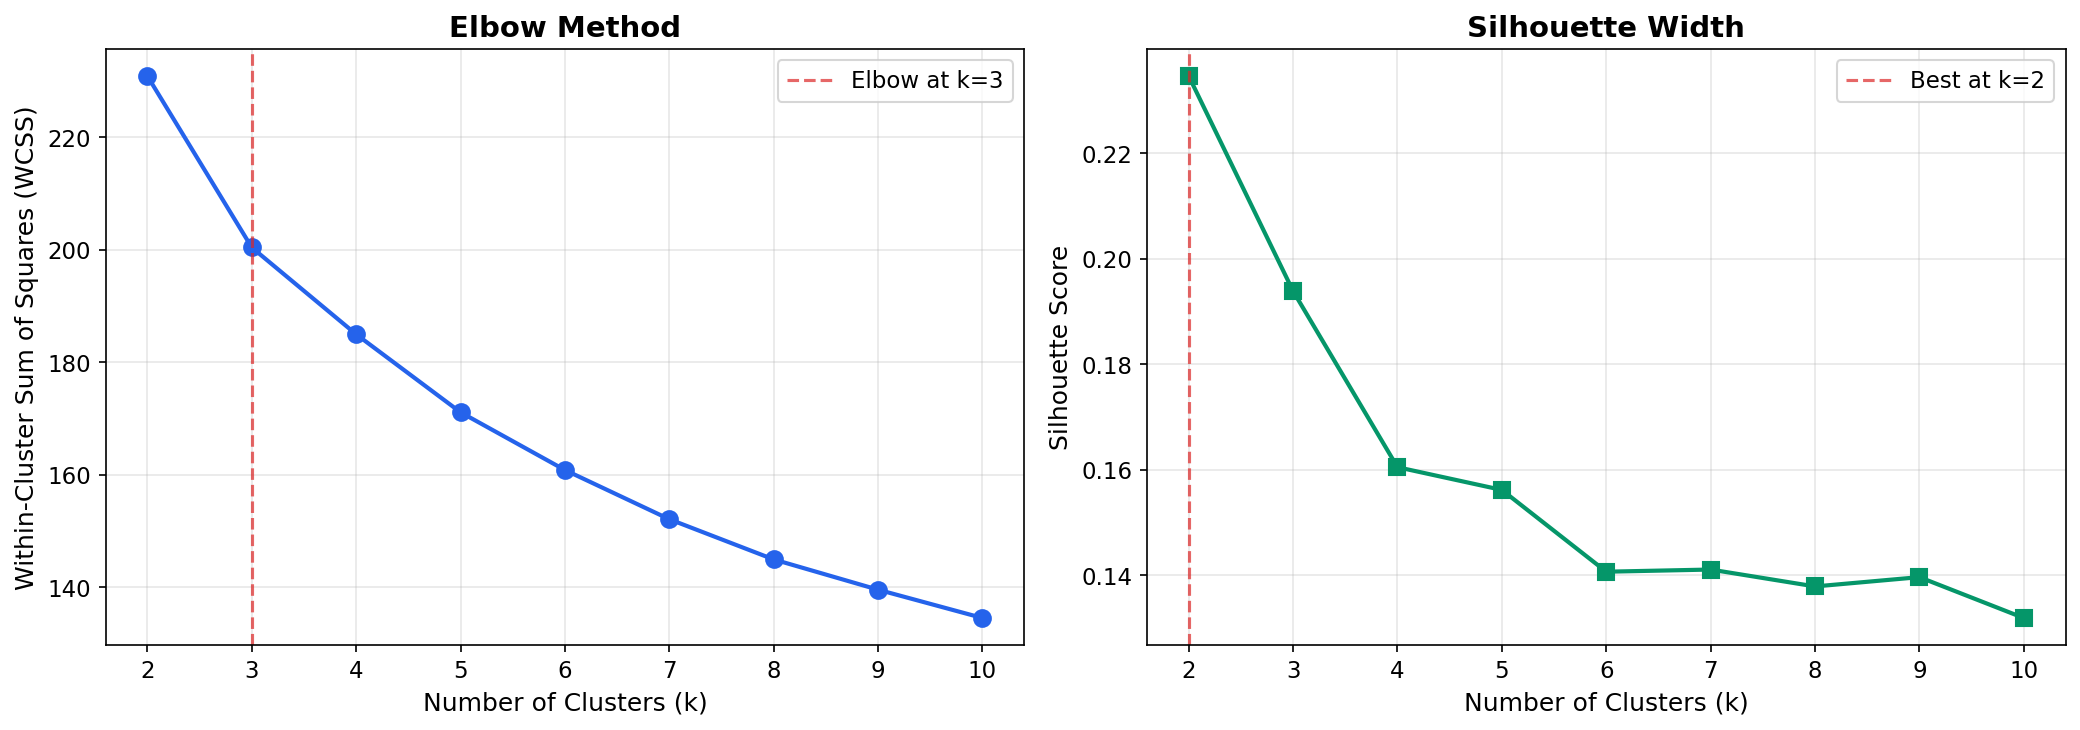

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), wcss, "o-", color="#2563eb", linewidth=2, markersize=8)
ax1.axvline(x=elbow_k, color="#dc2626", linestyle="--", alpha=0.7, label=f"Elbow at k={elbow_k}")
ax1.set_xlabel("Number of Clusters (k)", fontsize=12)
ax1.set_ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)
ax1.set_title("Elbow Method", fontsize=14, fontweight="bold")
ax1.set_xticks(list(K_RANGE))
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), sil_scores_list, "s-", color="#059669", linewidth=2, markersize=8)
ax2.axvline(x=best_sil_k, color="#dc2626", linestyle="--", alpha=0.7, label=f"Best at k={best_sil_k}")
ax2.set_xlabel("Number of Clusters (k)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Width", fontsize=14, fontweight="bold")
ax2.set_xticks(list(K_RANGE))
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. K-Means Clustering (k = 5)

Following the reference study, we apply K-Means with **k = 5** clusters. The algorithm uses:
- `n_init=50` (50 different centroid initializations to avoid local minima)
- `max_iter=1000` (sufficient convergence iterations)
- `random_state=42` (reproducibility)

In [25]:
OPTIMAL_K = 5

km_final = KMeans(n_clusters=OPTIMAL_K, n_init=50, max_iter=1000, random_state=42)
df["cluster"] = km_final.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df["cluster"])
print(f"Final silhouette score (k=5): {final_sil:.4f}")

print(f"\nCluster sizes:")
size_df = df["cluster"].value_counts().sort_index().to_frame("Count")
size_df["%"] = (size_df["Count"] / len(df) * 100).round(1)
display(size_df)

Final silhouette score (k=5): 0.1561

Cluster sizes:


,Count,%
cluster,,
0,250,18.2
1,416,30.2
2,363,26.4
3,72,5.2
4,275,20.0


---
## 6. Cluster Profile Table

Each cell shows **Median (Q1 - Q3)** for the given variable within each cluster.

In [26]:
def median_iqr(series):
    med = series.median()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{med:.1f} ({q1:.1f}\u2013{q3:.1f})"

profile_rows = []
for var in CLUSTERING_VARS:
    row = {"Variable": VAR_LABELS[var]}
    for c in sorted(df["cluster"].unique()):
        subset = df.loc[df["cluster"] == c, var]
        row[f"Cluster {c}"] = median_iqr(subset)
    row["Overall"] = median_iqr(df[var])
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("Variable")
display(profile_df)

profile_df.to_csv(os.path.join(OUTPUT_DIR, "cluster_profiles.csv"))
print("\nSaved to clustering_results/cluster_profiles.csv")

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Overall
Variable,,,,,,
Age (years),55.0 (54.0–58.0),59.0 (58.0–60.0),54.0 (53.0–55.0),55.0 (51.8–57.0),49.0 (47.0–50.0),55.0 (52.0–58.0)
HbA1c (%),5.9 (5.6–6.5),5.6 (5.4–5.9),5.5 (5.3–5.8),9.2 (8.6–10.9),5.6 (5.4–5.9),5.7 (5.4–6.0)
FBS (mg/dL),107.0 (100.0–120.0),101.0 (95.0–108.0),98.0 (93.0–104.0),233.0 (183.5–279.0),101.0 (95.0–110.5),102.0 (95.0–112.0)
BMI (kg/m²),40.1 (36.5–44.0),28.0 (24.5–31.9),26.1 (22.6–28.9),33.9 (29.1–37.9),31.1 (27.0–36.5),29.7 (25.5–35.7)
Total Chol. (mg/dL),191.0 (169.0–218.0),212.5 (186.0–240.0),218.0 (196.0–240.5),205.0 (174.8–240.8),200.0 (178.0–224.0),207.0 (181.0–234.0)
LDL (mg/dL),112.0 (90.2–136.8),127.0 (102.0–153.0),128.0 (109.0–149.0),112.2 (83.2–154.8),122.0 (103.0–143.0),123.0 (101.0–148.0)
HDL (mg/dL),50.5 (43.0–58.0),58.0 (48.0–69.0),64.0 (55.0–78.5),47.5 (41.0–52.0),51.0 (44.5–61.5),56.0 (47.0–67.2)
Triglycerides (mg/dL),111.0 (91.2–152.0),110.0 (80.0–152.4),92.0 (68.5–122.5),174.0 (126.1–260.9),103.0 (75.0–154.0),106.7 (77.0–149.0)
Systolic BP (mmHg),126.0 (118.0–137.0),124.0 (112.8–134.0),116.6 (108.0–128.0),129.0 (120.0–144.5),120.0 (110.0–130.0),122.0 (112.0–134.0)



Saved to clustering_results/cluster_profiles.csv


### 6a. Diabetes Status Distribution by Cluster

In [27]:
ct = pd.crosstab(df["cluster"], df["diabetes_status"], margins=True)
ct_pct = pd.crosstab(df["cluster"], df["diabetes_status"], normalize="index").round(3) * 100

print("Counts:")
display(ct)
print("\nRow-wise percentages (%):")
display(ct_pct.round(1))

Counts:


diabetes_status,Diabetic,Normal,Pre-diabetic,All
cluster,,,,
0,83,63,104,250
1,59,204,153,416
2,25,235,103,363
3,72,0,0,72
4,38,140,97,275
All,277,642,457,1376



Row-wise percentages (%):


diabetes_status,Diabetic,Normal,Pre-diabetic
cluster,,,
0,33.2,25.2,41.6
1,14.2,49.0,36.8
2,6.9,64.7,28.4
3,100.0,0.0,0.0
4,13.8,50.9,35.3


---
## 7. Phenotype Interpretation

Each cluster is assigned a clinical phenotype label based on its median metabolic profile, using thresholds from clinical guidelines:

| Marker | Threshold | Interpretation |
|--------|-----------|----------------|
| HbA1c | $\geq$ 7.0% | Poor glycemic control |
| HbA1c | 5.7 - 6.4% | Mild hyperglycemia / pre-diabetes |
| FBS | $\geq$ 126 mg/dL | Diabetic range |
| BMI | $\geq$ 35 | Severe obesity |
| BMI | 30 - 34.9 | Obese |
| Total Chol. | $\geq$ 240 | Dyslipidemia |
| Triglycerides | $\geq$ 200 | Hypertriglyceridemia |
| HDL | < 40 | Low HDL |
| SBP/DBP | $\geq$ 140/90 | Hypertensive |
| Waist Circ. | $\geq$ 110 cm | Central obesity |

In [28]:
cluster_medians = df.groupby("cluster")[CLUSTERING_VARS].median()

phenotype_labels = {}
for c in sorted(df["cluster"].unique()):
    m = cluster_medians.loc[c]
    traits = []

    if m["hba1c"] >= 7.0 or m["fbs"] >= 126:
        traits.append("Poor Glycemic Control")
    elif m["hba1c"] >= 5.7 or m["fbs"] >= 100:
        traits.append("Mild Hyperglycemia")

    if m["bmi"] >= 35:
        traits.append("Severe Obesity")
    elif m["bmi"] >= 30:
        traits.append("Obese")
    elif m["bmi"] >= 25:
        traits.append("Overweight")

    if m["total_cholesterol"] >= 240 or m["ldl"] >= 160:
        traits.append("Dyslipidemia")
    elif m["total_cholesterol"] >= 200 or m["ldl"] >= 130:
        traits.append("Borderline Lipids")

    if m["triglycerides"] >= 200:
        traits.append("High Triglycerides")

    if m["hdl"] < 40:
        traits.append("Low HDL")

    if m["systolic"] >= 140 or m["diastolic"] >= 90:
        traits.append("Hypertensive")
    elif m["systolic"] >= 130 or m["diastolic"] >= 85:
        traits.append("Elevated BP")

    if m["age"] >= 58:
        traits.append("Older")
    elif m["age"] <= 48:
        traits.append("Younger")

    if m["waist_circumference"] >= 110:
        traits.append("Central Obesity")

    if "Poor Glycemic Control" in traits:
        label = "Poor Glycemic Control"
    elif "Severe Obesity" in traits or ("Central Obesity" in traits and "Obese" in traits):
        label = "Severe Insulin-Resistant / Obesity-Related Diabetes (SIROD)"
    elif "Hypertensive" in traits:
        label = "Hypertensive Metabolic Syndrome"
    elif "Older" in traits and not any(t in traits for t in ["Obese", "Severe Obesity"]):
        label = "Mild Age-Related Diabetes (MARD)"
    elif "Dyslipidemia" in traits or "High Triglycerides" in traits:
        label = "Dyslipidemic Phenotype"
    elif "Obese" in traits and "Younger" in traits:
        label = "Younger Obese / Moderate Metabolic Risk"
    elif ("Overweight" in traits or "Obese" in traits) and "Mild Hyperglycemia" in traits:
        label = "Moderate Metabolic Risk"
    else:
        label = "Metabolically Healthier / Low-Risk"

    phenotype_labels[c] = label
    print(f"Cluster {c}: {label}")
    print(f"  Key traits: {', '.join(traits) if traits else 'Near-normal metabolic profile'}")
    print(f"  Age={m['age']:.0f} | BMI={m['bmi']:.1f} | HbA1c={m['hba1c']:.1f} | "
          f"FBS={m['fbs']:.0f} | SBP={m['systolic']:.0f} | Trig={m['triglycerides']:.0f}")
    print()

Cluster 0: Severe Insulin-Resistant / Obesity-Related Diabetes (SIROD)
  Key traits: Mild Hyperglycemia, Severe Obesity, Central Obesity
  Age=55 | BMI=40.1 | HbA1c=5.9 | FBS=107 | SBP=126 | Trig=111

Cluster 1: Mild Age-Related Diabetes (MARD)
  Key traits: Mild Hyperglycemia, Overweight, Borderline Lipids, Older
  Age=59 | BMI=28.0 | HbA1c=5.6 | FBS=101 | SBP=124 | Trig=110

Cluster 2: Metabolically Healthier / Low-Risk
  Key traits: Overweight, Borderline Lipids
  Age=54 | BMI=26.1 | HbA1c=5.5 | FBS=98 | SBP=117 | Trig=92

Cluster 3: Poor Glycemic Control
  Key traits: Poor Glycemic Control, Obese, Borderline Lipids, Central Obesity
  Age=55 | BMI=33.9 | HbA1c=9.2 | FBS=233 | SBP=129 | Trig=174

Cluster 4: Moderate Metabolic Risk
  Key traits: Mild Hyperglycemia, Obese, Borderline Lipids
  Age=49 | BMI=31.1 | HbA1c=5.6 | FBS=101 | SBP=120 | Trig=103



---
## 8. Visualizations

### 8a. Radar Chart (Normalized Cluster Medians)

Each axis represents one of the 11 clustering variables, scaled to [0, 1]. The radar chart allows visual comparison of all cluster profiles simultaneously.

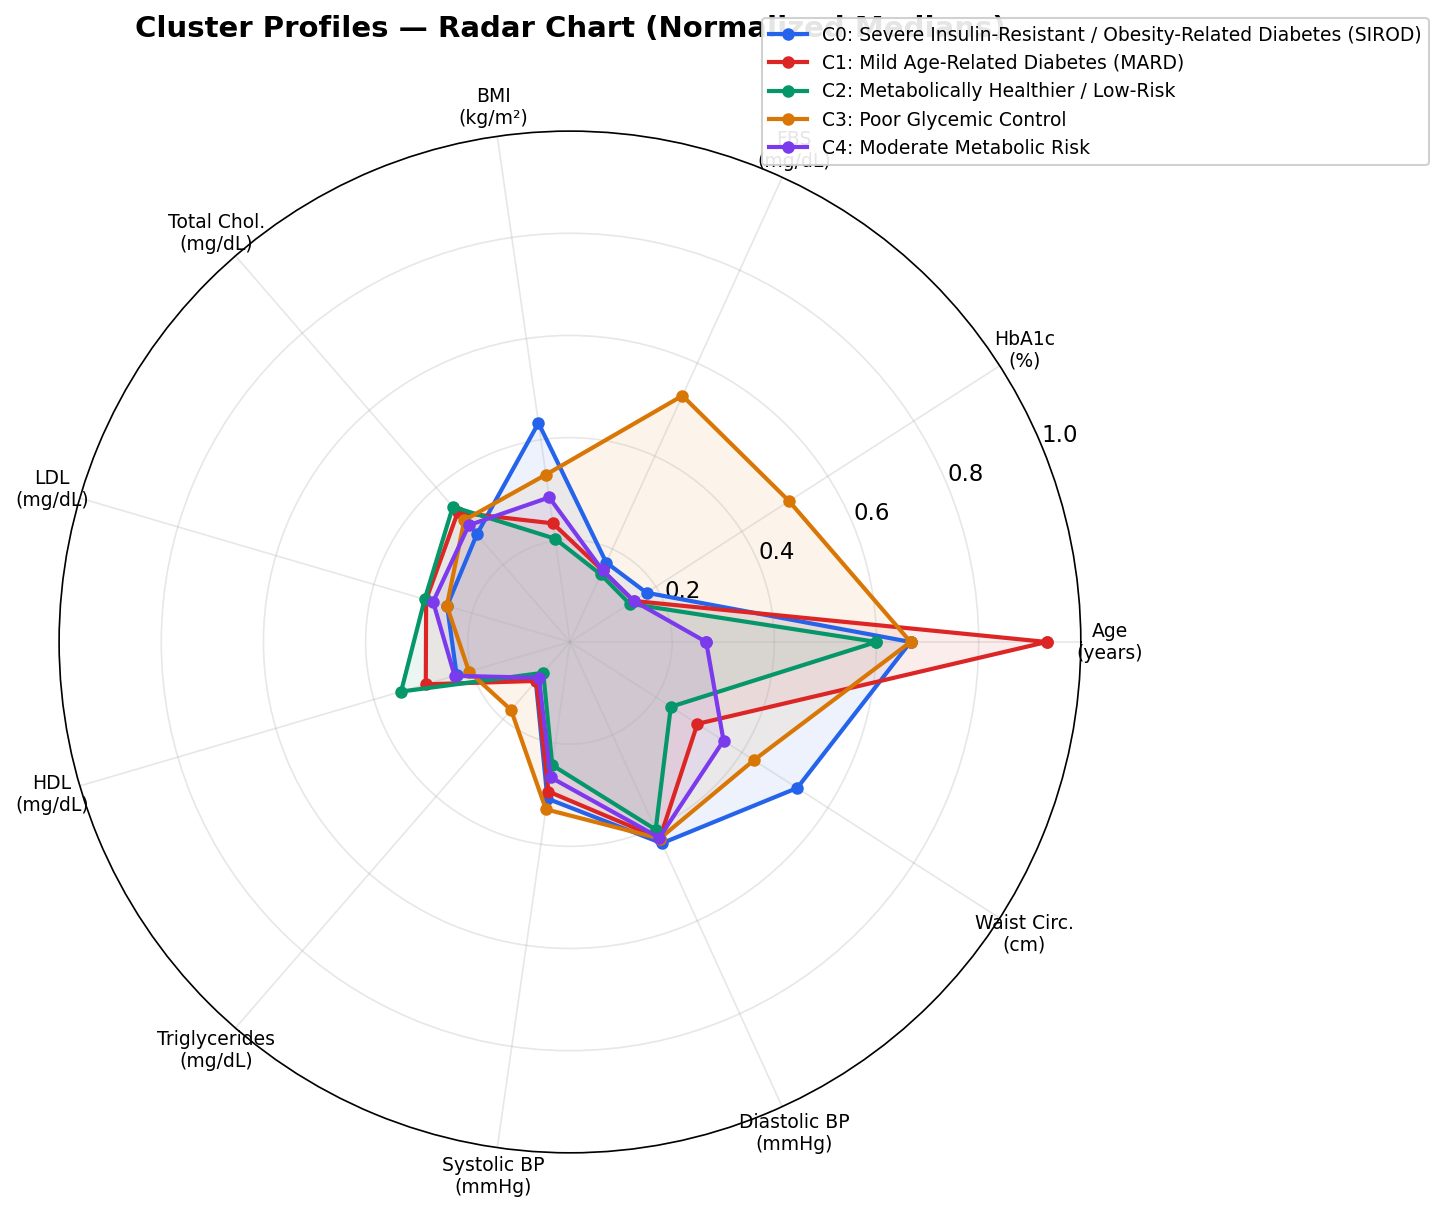

In [29]:
cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_medians),
    columns=CLUSTERING_VARS,
    index=cluster_medians.index
)

angles = np.linspace(0, 2 * np.pi, len(CLUSTERING_VARS), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for c in sorted(cluster_means_scaled.index):
    values = cluster_means_scaled.loc[c].tolist()
    values += values[:1]
    label = f"C{c}: {phenotype_labels[c]}"
    ax.plot(angles, values, "o-", linewidth=2, markersize=5, label=label, color=CLUSTER_COLORS[c])
    ax.fill(angles, values, alpha=0.08, color=CLUSTER_COLORS[c])

tick_labels = [VAR_LABELS[v].replace(" (", "\n(") for v in CLUSTERING_VARS]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Cluster Profiles \u2014 Radar Chart (Normalized Medians)", fontsize=14, fontweight="bold", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8b. Box Plots (Key Variable Distributions by Cluster)

Box plots show the full distribution (median, IQR, whiskers, outliers) for 8 key metabolic variables across all 5 clusters.

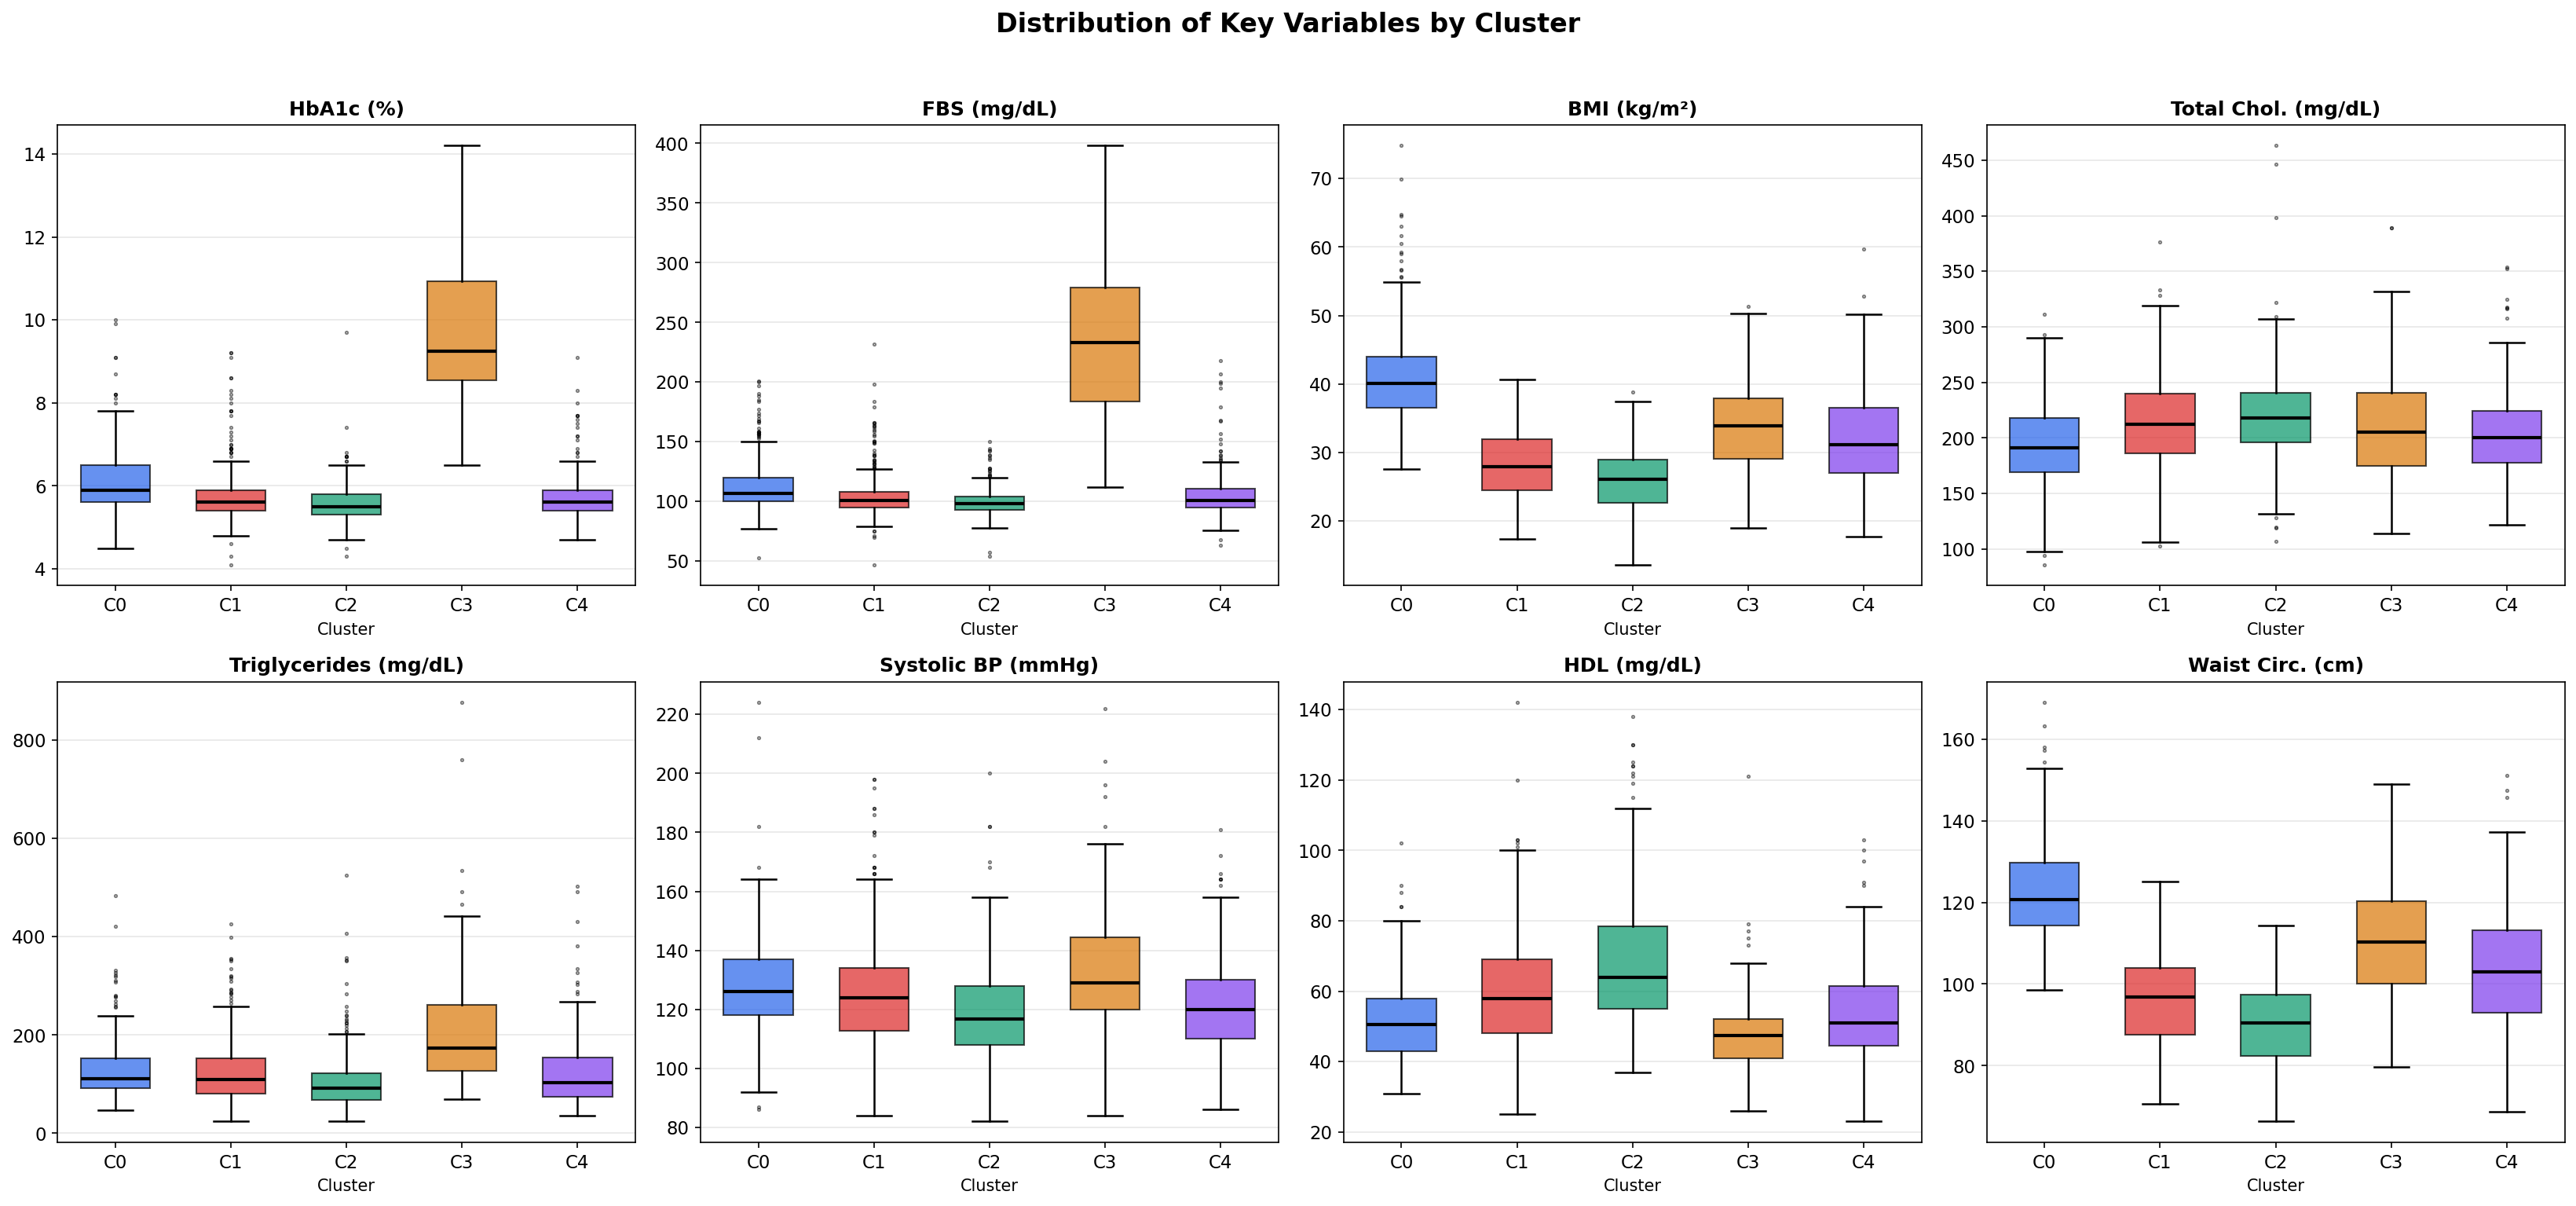

In [30]:
key_vars = ["hba1c", "fbs", "bmi", "total_cholesterol", "triglycerides",
            "systolic", "hdl", "waist_circumference"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    ax = axes[i]
    data_by_cluster = [df.loc[df["cluster"] == c, var].values for c in sorted(df["cluster"].unique())]

    bp = ax.boxplot(data_by_cluster,
                    labels=[f"C{c}" for c in sorted(df["cluster"].unique())],
                    patch_artist=True, widths=0.6,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker=".", markersize=3, alpha=0.5))

    for j, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(CLUSTER_COLORS[j])
        patch.set_alpha(0.7)

    ax.set_title(VAR_LABELS[var], fontsize=12, fontweight="bold")
    ax.set_xlabel("Cluster", fontsize=10)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Distribution of Key Variables by Cluster", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 8c. Silhouette Plot

The silhouette plot shows the silhouette coefficient for every individual patient, sorted within each cluster. Wider bars with higher coefficients indicate better-defined clusters.

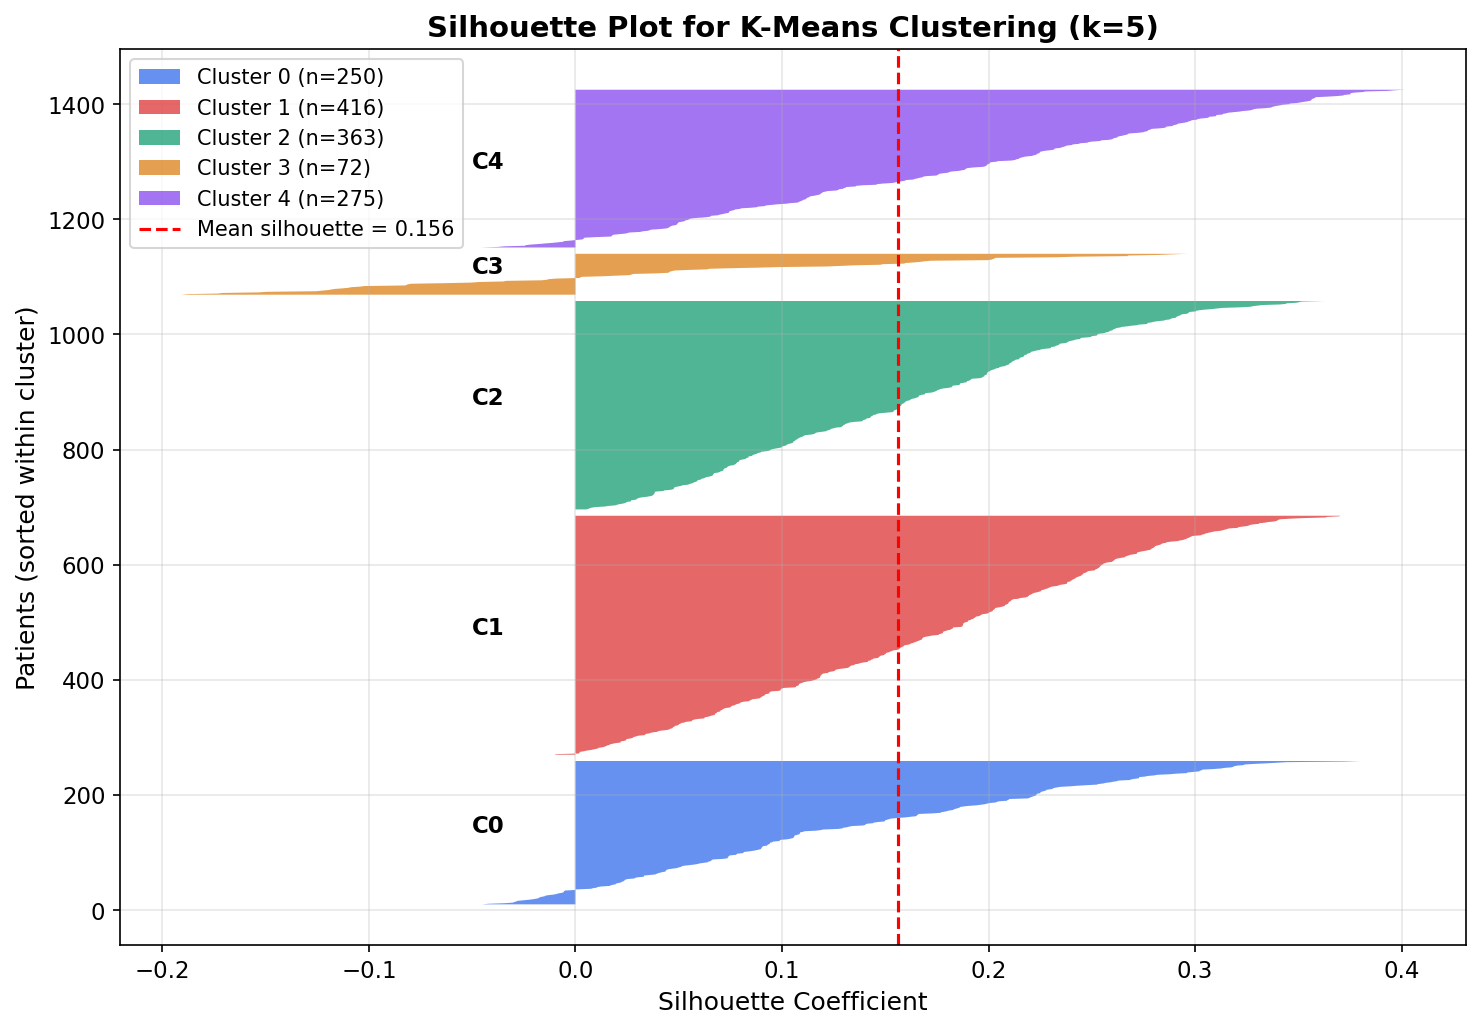

In [31]:
sil_vals = silhouette_samples(X_scaled, df["cluster"])
fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10
for c in sorted(df["cluster"].unique()):
    c_sil = np.sort(sil_vals[df["cluster"] == c])
    size = c_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=CLUSTER_COLORS[c], alpha=0.7,
                     label=f"Cluster {c} (n={size})")
    ax.text(-0.05, y_lower + 0.5 * size, f"C{c}", fontsize=11, fontweight="bold")
    y_lower = y_upper + 10

ax.axvline(x=final_sil, color="red", linestyle="--", linewidth=1.5,
           label=f"Mean silhouette = {final_sil:.3f}")
ax.set_xlabel("Silhouette Coefficient", fontsize=12)
ax.set_ylabel("Patients (sorted within cluster)", fontsize=12)
ax.set_title("Silhouette Plot for K-Means Clustering (k=5)", fontsize=14, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8d. Cluster Heatmap (Normalized Medians)

A heatmap of normalized median values across all 11 variables for each cluster, annotated with numeric values. Darker cells indicate higher relative values.

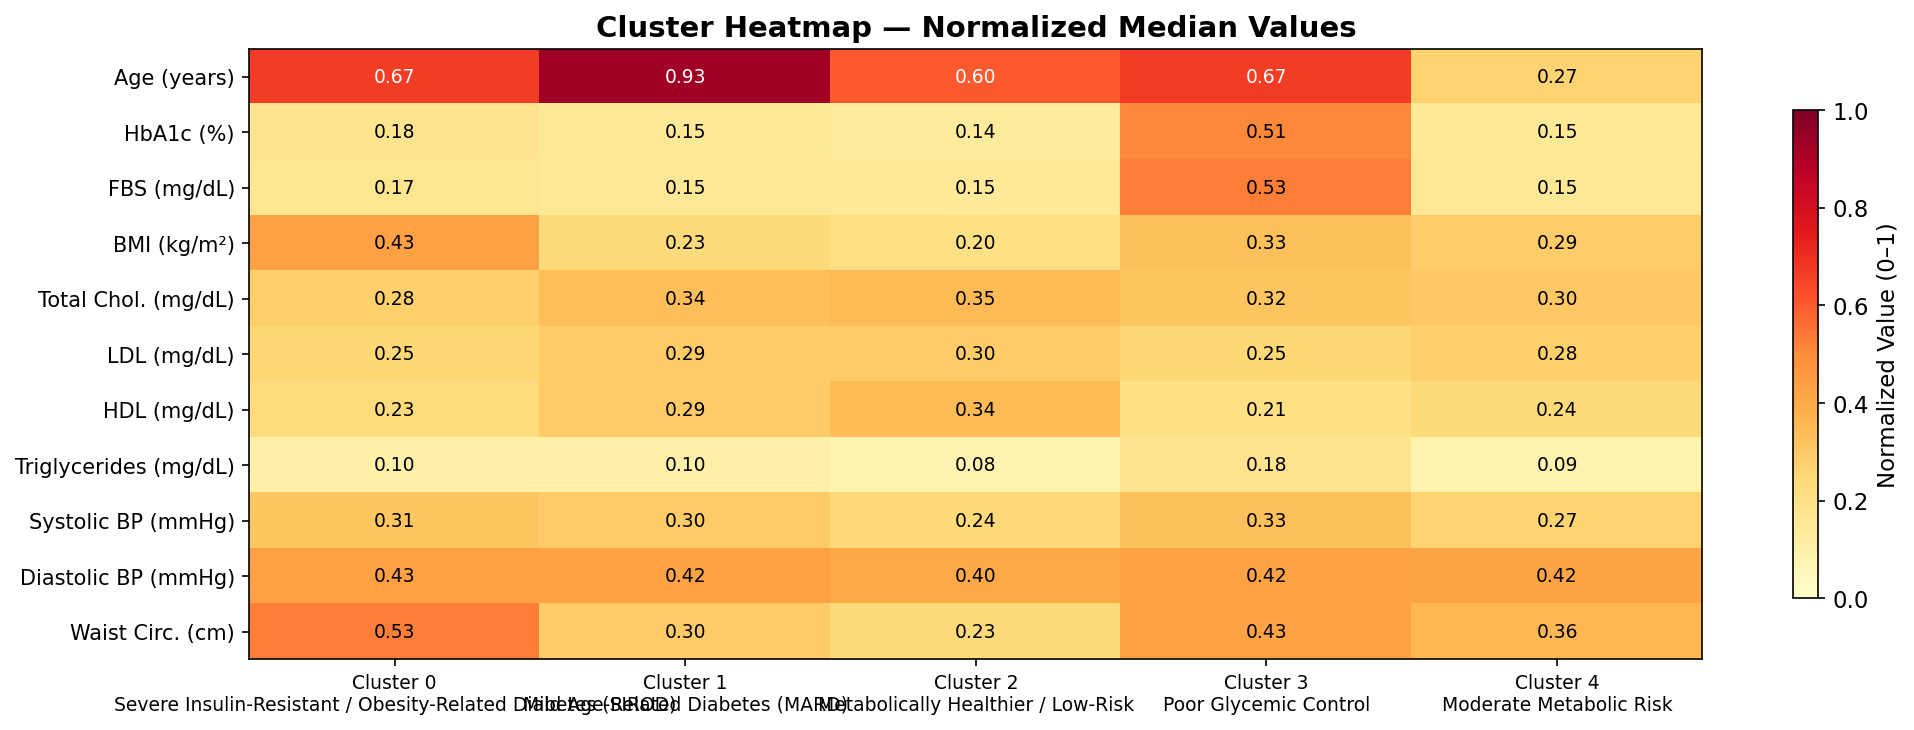

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))
heatmap_data = cluster_means_scaled.T.copy()
heatmap_data.index = [VAR_LABELS[v] for v in CLUSTERING_VARS]
heatmap_data.columns = [f"Cluster {c}\n{phenotype_labels[c]}" for c in heatmap_data.columns]

im = ax.imshow(heatmap_data.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=9, ha="center")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=10)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        color = "white" if val > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Normalized Value (0\u20131)", fontsize=11)
ax.set_title("Cluster Heatmap \u2014 Normalized Median Values", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

---
## 9. Comparison to Reference Study Phenotypes

The table below maps the 5 identified clusters from the Diana dataset to the common diabetes phenotypes described in the 2025 systematic review.

| Reference Phenotype | Description | Diana Cluster |
|---------------------|-------------|---------------|
| **MARD** (Mild Age-Related Diabetes) | Older patients, mild metabolic abnormalities, near-normal HbA1c/FBS, low obesity | Cluster 1 |
| **SIROD** (Severe Insulin-Resistant / Obesity-Related) | High BMI, central obesity, insulin resistance markers, elevated triglycerides | Cluster 0 |
| **Poor Glycemic Control** | Markedly elevated HbA1c ($\geq$7%) and FBS ($\geq$126 mg/dL), variable obesity | Cluster 3 |
| **Moderate Metabolic Risk** | Younger patients with obesity, mild metabolic disturbances | Cluster 4 |
| **Metabolically Healthier / Low-Risk** | Near-normal values across most metabolic markers | Cluster 2 |

In [33]:
print("Diana dataset cluster -> phenotype assignments:\n")
for c in sorted(phenotype_labels.keys()):
    n = (df["cluster"] == c).sum()
    pct = n / len(df) * 100
    print(f"  Cluster {c} ({n} patients, {pct:.1f}%) -> {phenotype_labels[c]}")

Diana dataset cluster -> phenotype assignments:

  Cluster 0 (250 patients, 18.2%) -> Severe Insulin-Resistant / Obesity-Related Diabetes (SIROD)
  Cluster 1 (416 patients, 30.2%) -> Mild Age-Related Diabetes (MARD)
  Cluster 2 (363 patients, 26.4%) -> Metabolically Healthier / Low-Risk
  Cluster 3 (72 patients, 5.2%) -> Poor Glycemic Control
  Cluster 4 (275 patients, 20.0%) -> Moderate Metabolic Risk


---
## Summary of Findings

The K-Means cluster analysis (k=5) on the Diana dataset identified **five distinct diabetes phenotypes**:

| Cluster | Phenotype | n | Key Distinguishing Features |
|---------|-----------|---|-----------------------------|
| **C0** | SIROD | 250 (18.2%) | Severe obesity (BMI 40.1), central adiposity (WC 120.6 cm) |
| **C1** | MARD | 416 (30.2%) | Oldest group (age 59), overweight, mild hyperglycemia |
| **C2** | Metabolically Healthier | 363 (26.4%) | Lowest HbA1c (5.5), FBS (98), best HDL (64), lowest triglycerides (92) |
| **C3** | Poor Glycemic Control | 72 (5.2%) | HbA1c **9.2**, FBS **233**, 100% diabetic |
| **C4** | Moderate Metabolic Risk | 275 (20.0%) | Youngest group (age 49), obese (BMI 31.1), mild hyperglycemia |

### Key Observations

1. **MARD** is the largest cluster (30.2%), consistent with the literature showing age-related mild diabetes as the most prevalent phenotype.
2. **Cluster 3 (Poor Glycemic Control)** is small (5.2%) but clinically critical: 100% of patients are diabetic with severely elevated HbA1c and FBS.
3. **SIROD (Cluster 0)** captures the obesity-driven metabolic phenotype with BMI > 40 and waist circumference > 120 cm.
4. **Cluster 2** represents the metabolically healthiest group with the best lipid profile and lowest glycemic markers.
5. No pure **Hypertensive Metabolic Syndrome** cluster emerged, suggesting blood pressure variation in this cohort was less discriminating than glycemic and obesity markers.